# Базовый эксперимент на сфере и визуализация

В этом ноутбуке мы проверим функционал сложности
$$
C(X) \;=\; \log\det(I + K)
$$
на простейшем случае — единичной сфере $S^2 \subset \mathbb{R}^3$ с равномерным распределением точек.

Для $S^2$ мы знаем оператор Лапласа–Бельтрами, его спектр и тепловое ядро в замкнутой форме. Это позволяет:

1. собрать матрицу ядра $K$ из **аналитического** теплового ядра $h_t(x,y)$, не используя diffusion maps;
2. проверить, что функционал $C(X) = \log\det(I+K)$ обладает заявленными свойствами (PSD, инвариантность к перестановкам и поворотам, монотонность, субаддитивность, субмодулярность);

В этом эксперименте **score равен нулю**, поэтому метрический тензор сводится к евклидову, $g = I$, а тепловое ядро — это классическое тепловое ядро на $S^2$.

## Аналитические объекты на $S^2$

### Оператор Лапласа–Бельтрами

В сферических координатах $(\theta,\varphi)$, $\theta \in [0,\pi]$, $\varphi \in [0, 2\pi)$:
$$
\Delta_{S^2} f \;=\; \frac{1}{\sin\theta}\partial_\theta(\sin\theta\,\partial_\theta f) \;+\; \frac{1}{\sin^2\theta}\partial_\varphi^2 f.
$$

### Спектр и собственные функции

Собственные функции — сферические гармоники $Y_{\ell m}$:
$$
-\Delta_{S^2}\, Y_{\ell m} \;=\; \ell(\ell+1)\, Y_{\ell m},
\qquad
\ell = 0, 1, 2, \dots, \quad m = -\ell, \dots, \ell.
$$
Кратность собственного значения $\lambda_\ell = \ell(\ell+1)$ равна $2\ell+1$.

### Тепловое ядро

$$
h_t(x,y) \;=\; \sum_{\ell=0}^{\infty} e^{-t\,\ell(\ell+1)} \,\frac{2\ell+1}{4\pi}\, P_\ell(\langle x, y\rangle),
$$
где $\langle x, y\rangle = \cos\gamma$ — косинус геодезического угла, $P_\ell$ — полиномы Лежандра. Ряд сходится экспоненциально быстро для любого $t > 0$, поэтому в численной реализации мы обрезаем на достаточно большом $L$.

### Геодезическое расстояние

$$
d_{S^2}(x, y) \;=\; \arccos(\langle x, y\rangle).
$$

### Выбор масштаба $t$
$t$ — параметр геометрического разрешения.
- **Median** по геодезическим расстояниям: $t \sim \mathrm{median}\{d_g(x_i, x_j)^2\}$.
- **Спектральный gap**: $t \sim 1/\lambda_2$, где $\lambda_2$ — первое ненулевое собственное значение $-\Delta_g$.
- **Диаметр**: $t \ll \mathrm{diam}(\mathcal{M})^2$ — иначе ядро становиться константой.

Для $S^2$ ($\mathrm{diam} = \pi$, $\mathrm{vol} = 4\pi$) информативный диапазон — $t \in [0.01, 1]$. Это видно в эксперименте C: ниже $10^{-2}$ кривая упирается в $N\log 2$, выше $10^1$ — в $\log(1+N)$.

### Программа экспериментов
1. равномерная выборка на $S^2$, визуализация.
2. **Heat kernel** — реализация и визуализация $h_t(N, \cdot)$.
3. **Properties** — PSD, перестановочная и вращательная инвариантности.
4. **A** — $N$ копий одной точки, проверка $C(X) = \log(1+N)$.
5. **B** — $N$ Разреженных точек (с помощью спирали Фибоначчи), проверка $C(X) = N\log 2$.
6. **C** — фиксированная выборка, развёртка по $t$ — интерполяция между B и A.
7. **D** — растущее $N$ равномерных точек на $S^2$ при фиксированных $t$ — поведение между двумя предельными режимами; ожидаем суб-линейный рост $C(X) \sim M_{\mathrm{eff}}(t) \log N$, где $M_{\mathrm{eff}}(t)$ — эффективное число активных мод heat operator.


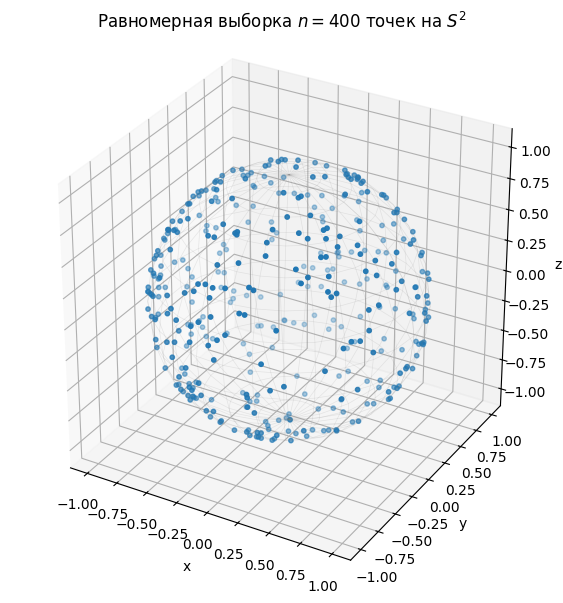

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rng = np.random.default_rng(0)


def sample_sphere_uniform(n, rng):
    pts = rng.standard_normal((n, 3))
    pts /= np.linalg.norm(pts, axis=1, keepdims=True)
    return pts


pts = sample_sphere_uniform(400, rng)
assert np.allclose(np.linalg.norm(pts, axis=1), 1.0)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), color='gray', alpha=0.15, linewidth=0.5)

ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=10, c='C0', depthshade=True)
ax.set_box_aspect((1, 1, 1))
ax.set_title(r'Равномерная выборка $n=400$ точек на $S^2$')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()


$L$, при котором $exp\{-t L (L+1)\}$ < tol — обрезаем хвост ряда.

Решаем неравенство 
$$tL(L+1) > -log(tol)$$
$$L > (-1 + sqrt(1 - 4 log(tol) / t)) / 2$$
Для t >= 1e-3 и tol = 1e-12 даёт L_max ~ 165, чего более чем достаточно.

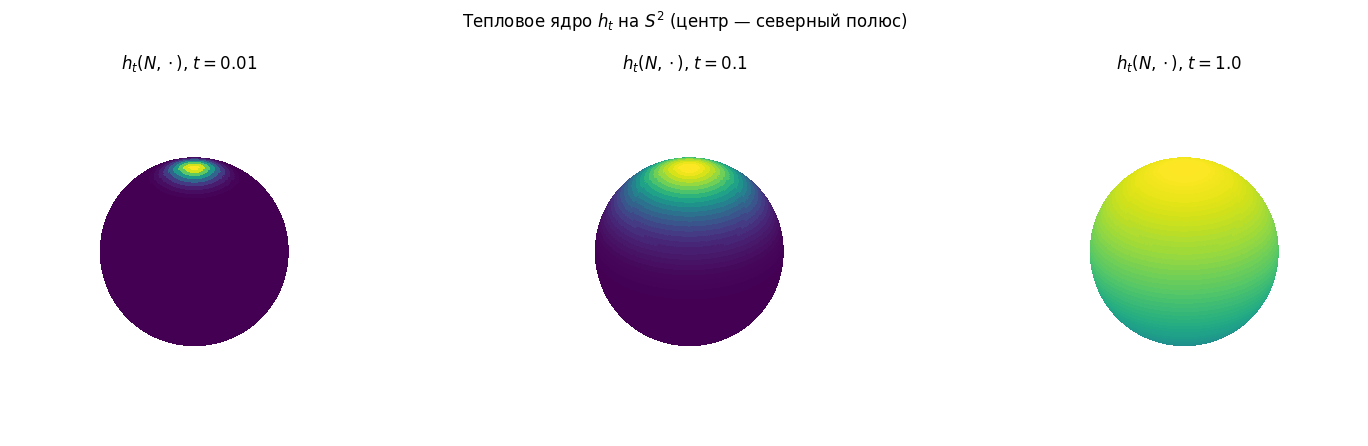

h_t(x, x) для пяти случайных точек, t=0.1: [0.82284142 0.82284142 0.82284142 0.82284142 0.82284142]
разброс относительно среднего: 3.02e-16


In [2]:
def _auto_L_max(t, tol=1e-12):
    L = int(np.ceil(0.5 * (-1.0 + np.sqrt(1.0 - 4.0 * np.log(tol) / max(t, 1e-12)))))
    return max(L, 1)


def heat_kernel_S2(X, Y, t, tol=1e-12):
    L_max = _auto_L_max(t, tol)
    cos_g = np.clip(X @ Y.T, -1.0, 1.0)

    P_prev = np.ones_like(cos_g)
    K = (1.0 / (4.0 * np.pi)) * P_prev
    P_curr = cos_g
    K += np.exp(-t * 2.0) * (3.0 / (4.0 * np.pi)) * P_curr

    for l in range(1, L_max):
        P_next = ((2 * l + 1) * cos_g * P_curr - l * P_prev) / (l + 1)
        l1 = l + 1
        K += np.exp(-t * l1 * (l1 + 1)) * (2 * l1 + 1) / (4 * np.pi) * P_next
        P_prev, P_curr = P_curr, P_next
    return K


# h_t(N, .) на сфере
north = np.array([[0.0, 0.0, 1.0]])

n_grid = 60
theta = np.linspace(0, np.pi, n_grid)
phi = np.linspace(0, 2 * np.pi, 2 * n_grid)
TH, PH = np.meshgrid(theta, phi, indexing='ij')
X_grid = np.stack([np.sin(TH) * np.cos(PH),
                   np.sin(TH) * np.sin(PH),
                   np.cos(TH)], axis=-1)
flat_grid = X_grid.reshape(-1, 3)

ts_show = (0.01, 0.1, 1.0)
fig = plt.figure(figsize=(15, 4.5))
for j, t in enumerate(ts_show):
    K_col = heat_kernel_S2(flat_grid, north, t).reshape(TH.shape)
    K_norm = K_col / K_col.max()
    ax = fig.add_subplot(1, 3, j + 1, projection='3d')
    ax.plot_surface(X_grid[..., 0], X_grid[..., 1], X_grid[..., 2], facecolors=plt.cm.viridis(K_norm), rstride=1, cstride=1, antialiased=False, shade=False)
    ax.scatter(*north.T, color='red', s=40)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title(rf'$h_{{t}}(N, \cdot)$, $t={t}$')
    ax.set_axis_off()
plt.suptitle(r'Тепловое ядро $h_t$ на $S^2$ (центр — северный полюс)')
plt.tight_layout()
plt.show()

# проверка однородности
diag_vals = np.diag(heat_kernel_S2(pts[:5], pts[:5], t=0.1))
print(f'h_t(x, x) для пяти случайных точек, t=0.1: {diag_vals}')
print(f'разброс относительно среднего: {diag_vals.std() / diag_vals.mean():.2e}')


## Функционал сложности и базовые свойства

Для дискретной выборки положим
$$
K_{ij} \;=\; \frac{h_t(x_i, x_j)}{h_t(x, x)},
$$
поделив на $h_t(x, x)$ — это **константа на $S^2$** в силу однородности (изотропии оператора Лапласа). После нормировки $K_{ii} = 1$, и предсказанные асимптотики $\log(1+N)$ и $N\log 2$ выполняются буквально.

Сам функционал — стандартный лог-определитель:
$$
C(X) \;=\; \log\det(I + K) \;=\; \sum_{i=1}^n \log(1 + \sigma_i),
$$
где $\sigma_i$ — собственные значения $K$.

Проверим **PSD** ($K \succeq 0$) численно — это следует из спектрального разложения $h_t = \sum_\ell e^{-t\lambda_\ell}\phi_\ell\phi_\ell$ (Лемма 1). Перестановочная и вращательная инвариантности — очевидно: $C$ зависит только от спектра $K$, а $h_t$ — только от $\langle x, y\rangle$.


In [3]:
def normalised_K(X, t):
    K = heat_kernel_S2(X, X, t)
    return K / K[0, 0]


def complexity(K, jitter=1e-12):
    n = K.shape[0]
    M = np.eye(n) + K + jitter * np.eye(n)
    L = np.linalg.cholesky(M)
    return float(2.0 * np.sum(np.log(np.diag(L))))


# PSD-проверка
X = sample_sphere_uniform(50, np.random.default_rng(42))
print(f"{'t':>8} {'lambda_min(K)':>16} {'C(X)':>10}")
for t in (0.01, 0.1, 1.0, 10.0):
    K = normalised_K(X, t)
    lam_min = np.linalg.eigvalsh(0.5 * (K + K.T)).min()
    print(f"{t:>8} {lam_min:>16.3e} {complexity(K):>10.4f}")


       t    lambda_min(K)       C(X)
    0.01        4.781e-02    33.1006
     0.1        3.342e-04    24.8556
     1.0       -3.086e-15     9.1481
    10.0       -1.312e-14     3.9318


## Эксперимент A: $N$ копий одной точки $\Rightarrow C(X) = \log(1+N)$

Это самая жёсткая проверка субаддитивности и «избыточности». Если все точки совпадают, то после нормировки
$$
K = \mathbf{1}\mathbf{1}^\top, \qquad \operatorname{spec}(K) = \{N,\;0,\dots,0\},
$$
и значит
$$
C(X) \;=\; \log(1 + N).
$$
Сложность растёт **логарифмически** по $N$ — каждый дубликат даёт $\sim 1/N$ бит, потому что полностью предсказуем по уже имеющимся (см. формулу (19)).

В нашей постановке выборка лежит на $S^2$, score $=0$, и $h_t(x_i, x_j) = h_t(x, x)$ при $x_i = x_j$ — однородность. Поэтому результат тривиально не зависит ни от $t$, ни от выбора $x_0$ — берём один фиксированный $t = 0.1$.

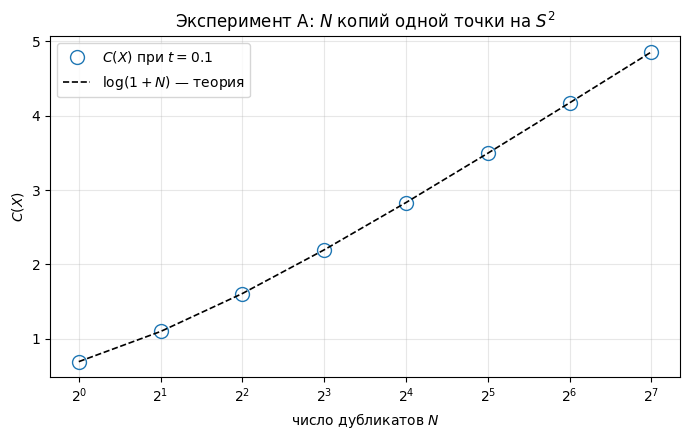

In [4]:
N_grid = np.array([1, 2, 4, 8, 16, 32, 64, 128])
x0 = sample_sphere_uniform(1, np.random.default_rng(7))
t = 0.1

C_A = np.array([complexity(normalised_K(np.tile(x0, (N, 1)), t)) for N in N_grid])
theory_A = np.log(1 + N_grid)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(N_grid, C_A, 'o', ms=10, mfc='none', color='C0',
        label=fr'$C(X)$ при $t={t}$')
ax.plot(N_grid, theory_A, 'k--', lw=1.2, label=r'$\log(1+N)$ — теория')
ax.set_xscale('log', base=2)
ax.set_xlabel('число дубликатов $N$')
ax.set_ylabel(r'$C(X)$')
ax.set_title(r'Эксперимент A: $N$ копий одной точки на $S^2$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Эксперимент B: $N$ максимально разнесённые точек $\Rightarrow C(X) \to N\log 2$

Противоположный предельный режим. Если точки разнесены так, что недиагональные $K_{ij} \to 0$, то $K \to I$ и
$$
C(X) \;=\; \sum_{i=1}^n \log(1 + \sigma_i) \;\to\; N \log 2.
$$
Это **верхняя граница** на удельный вклад одной точки $\le \log 2$.

Чтобы получить максимально разнесённые точки на $S^2$, используем спираль Фибоначчи. Чтобы $K_{ij} \to 0$, берём **малое $t$** — короткое время диффузии, тепло не успевает «перемешать» точки. По формуле Варадхана $h_t(x, y) \sim e^{-d_g(x,y)^2/4t}$ при $t \to 0^+$, поэтому недиагональные убывает экспоненциально.


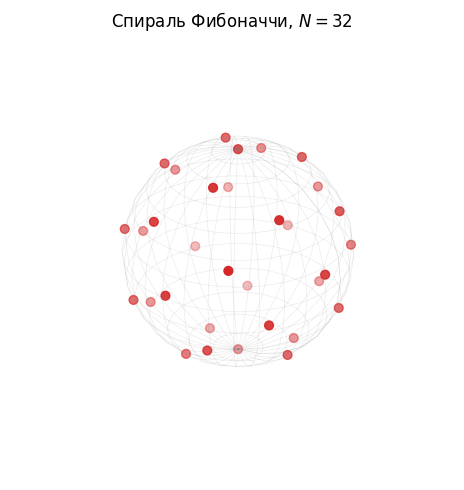

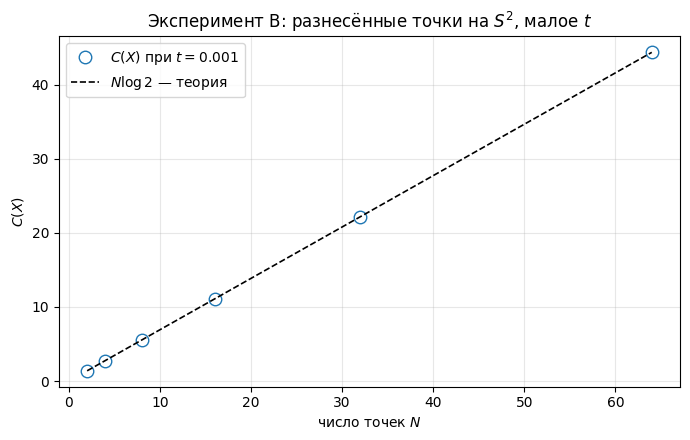

In [5]:
def fibonacci_sphere(n):
    if n == 1:
        return np.array([[0.0, 0.0, 1.0]])
    phi = np.pi * (3.0 - np.sqrt(5.0))
    i = np.arange(n)
    z = 1.0 - 2.0 * i / (n - 1)
    r = np.sqrt(np.maximum(0.0, 1.0 - z * z))
    theta = phi * i
    return np.stack([r * np.cos(theta), r * np.sin(theta), z], axis=1)


# визуализация точек
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gray', alpha=0.15, linewidth=0.5)
demo = fibonacci_sphere(32)
ax.scatter(demo[:, 0], demo[:, 1], demo[:, 2], s=40, c='C3')
ax.set_box_aspect((1, 1, 1))
ax.set_title('Спираль Фибоначчи, $N=32$')
ax.set_axis_off()
plt.tight_layout(); plt.show()

N_grid = np.array([2, 4, 8, 16, 32, 64])
t_small = 1e-3
results_B = []
for N in N_grid:
    Xs = fibonacci_sphere(N)
    K = normalised_K(Xs, t_small)
    results_B.append(complexity(K))

theory_B = N_grid * np.log(2)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(N_grid, results_B, 'o', ms=9, mfc='none', label=fr'$C(X)$ при $t={t_small}$')
ax.plot(N_grid, theory_B, 'k--', lw=1.2, label=r'$N\log 2$ — теория')
ax.set_xlabel('число точек $N$')
ax.set_ylabel(r'$C(X)$')
ax.set_title(r'Эксперимент B: разнесённые точки на $S^2$, малое $t$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Эксперимент C: интерполяция между $\log(1+N)% и %N\log 2$ через $t$

**для одной и той же выборки** функционал $C(X)$ при росте $t$ непрерывно стягивается с верхней границы $N\log 2$ к нижней $\log(1+N)$:

- **малое $t$**:точки фактически независимы, $K \to I$, $C \to N\log 2$;
- **большое $t$**: $h_t \to \mathrm{vol}(S^2)^{-1} = 1/(4\pi)$, после нормировки $K \to \mathbf{1}\mathbf{1}^\top$, $C \to \log(1+N)$.

То есть $t$ - **масштаб геометрического разрешения**: в нашей итоговой конструкции через score-induced metric тот же параметр будет регулировать, на каком масштабе данные считаются «одинаковыми».

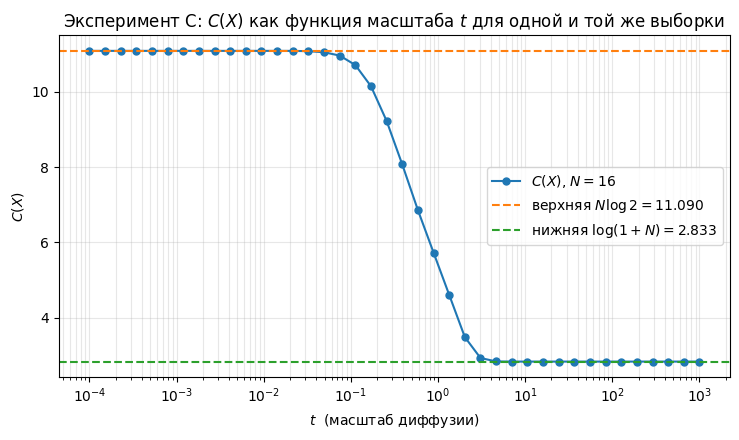

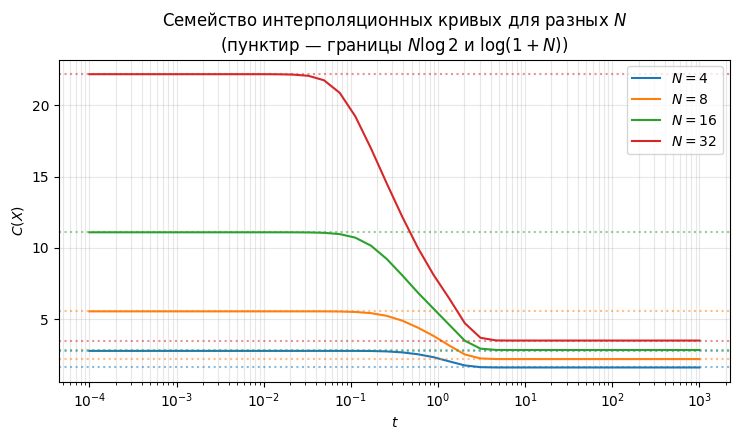

In [6]:
N = 16
Xs = fibonacci_sphere(N)
ts = np.geomspace(1e-4, 1e3, 40)
Cs = np.array([complexity(normalised_K(Xs, t)) for t in ts])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ts, Cs, 'o-', ms=5, label=fr'$C(X)$, $N={N}$')
ax.axhline(N * np.log(2),  color='C1', ls='--',
           label=fr'верхняя $N\log 2 = {N*np.log(2):.3f}$')
ax.axhline(np.log(1 + N),  color='C2', ls='--',
           label=fr'нижняя $\log(1+N) = {np.log(1+N):.3f}$')
ax.set_xscale('log')
ax.set_xlabel(r'$t$  (масштаб диффузии)')
ax.set_ylabel(r'$C(X)$')
ax.set_title(r'Эксперимент C: $C(X)$ как функция масштаба $t$ для одной и той же выборки')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for N in (4, 8, 16, 32):
    Xs = fibonacci_sphere(N)
    Cs = np.array([complexity(normalised_K(Xs, t)) for t in ts])
    line, = ax.plot(ts, Cs, '-', label=fr'$N={N}$')
    ax.axhline(N * np.log(2), color=line.get_color(), ls=':', alpha=0.5)
    ax.axhline(np.log(1 + N), color=line.get_color(), ls=':', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$C(X)$')
ax.set_title('Семейство интерполяционных кривых для разных $N$\n'
             r'(пунктир — границы $N\log 2$ и $\log(1+N)$)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Эксперимент D: рост $N$ при равномерной выборке на $S^2$

берём равномерную выборку растущего размера $N$ на $S^2$ и смотрим, как $C(X)$ ведёт себя при нескольких фиксированных $t$.

Ожидание: кривая $C(N)$ зажата между $\log(1+N)$ снизу (предел A) и $N\log 2$ сверху (предел B). Меньшее $t$ — ближе к верхней границе, большее $t$ — к нижней.


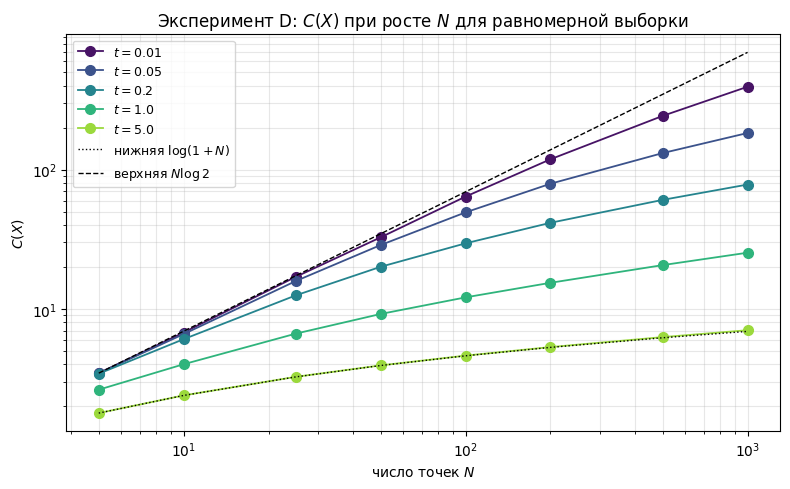

In [7]:
N_grid = np.array([5, 10, 25, 50, 100, 200, 500, 1000])
ts = (0.01, 0.05, 0.2, 1.0, 5.0)

results_D = {t: [] for t in ts}
rng_D = np.random.default_rng(123)

for N in N_grid:
    Xs = sample_sphere_uniform(N, rng_D)
    for t in ts:
        results_D[t].append(complexity(normalised_K(Xs, t)))

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(ts)))
for t, c in zip(ts, colors):
    ax.plot(N_grid, results_D[t], 'o-', color=c, ms=7, lw=1.3,
            label=fr'$t={t}$')

ax.plot(N_grid, np.log(1 + N_grid), 'k:',  lw=1.0, label=r'нижняя $\log(1+N)$')
ax.plot(N_grid, N_grid * np.log(2), 'k--', lw=1.0, label=r'верхняя $N\log 2$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('число точек $N$')
ax.set_ylabel(r'$C(X)$')
ax.set_title(r'Эксперимент D: $C(X)$ при росте $N$ для равномерной выборки')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Субаддитивность и субмодулярность $C(X)$

Из положительной полуопределённости $K\succeq 0$ для $C(S) = \log\det(I + K_S)$ теоретически известно:

- **Субаддитивность.** Для непересекающихся $A, B$:
$$
C(A\cup B) \;\le\; C(A) + C(B).
$$
- **Субмодулярность.** Для $A\subseteq B$, $i\notin B$:
$$
C(A\cup\{i\}) - C(A) \;\ge\; C(B\cup\{i\}) - C(B).
$$

Проверяем обе численно. Берём $N=80$ равномерно распределённых точек на $S^2$, $t=0.1$, и $500$ случайных троек: для субаддитивности — независимые подмножества $A, B$; для субмодулярности — вложенные $A\subset B$ и точка $i\notin B$.

субаддитивность: 500 испытаний, min(C(A)+C(B) - C(A∪B)) = 1.661e-02, доля выполнения = 1.000
субмодулярность: 500 испытаний, min(ΔA - ΔB) = 1.299e-07, доля выполнения = 1.000


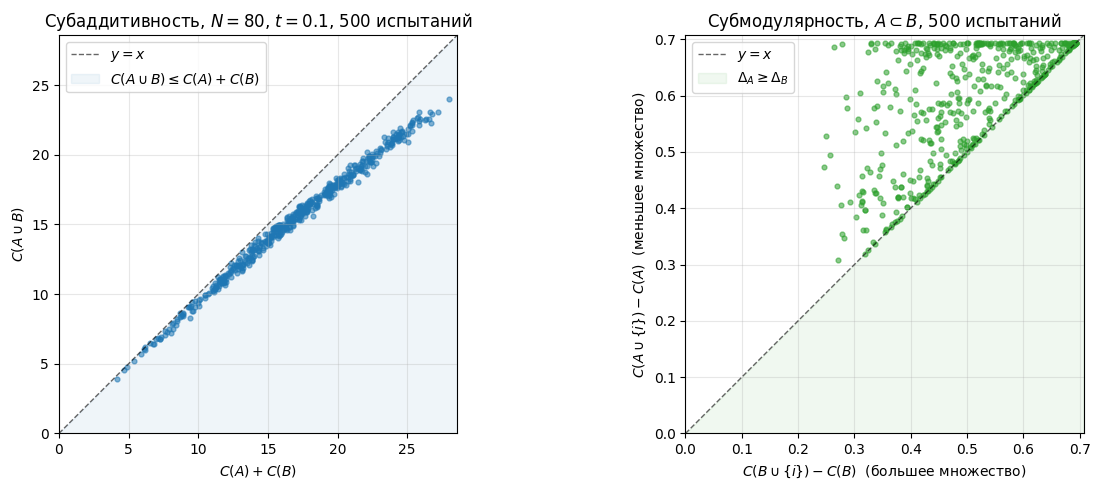

In [8]:
rng_sm = np.random.default_rng(2026)
N_test = 80
X_test = sample_sphere_uniform(N_test, rng_sm)
t_test = 0.1


def C_on(idx):
    if len(idx) == 0:
        return 0.0
    K = heat_kernel_S2(X_test[idx], X_test[idx], t_test)
    K = K / K[0, 0]
    K = 0.5 * (K + K.T)
    return float(np.linalg.slogdet(np.eye(len(K)) + K)[1])


n_trials = 500

sub_data = []
for _ in range(n_trials):
    perm = rng_sm.permutation(N_test)
    nA = int(rng_sm.integers(3, 25)); nB = int(rng_sm.integers(3, 25))
    A = perm[:nA]; B = perm[nA:nA + nB]
    cA = C_on(A); cB = C_on(B)
    cAB = C_on(np.concatenate([A, B]))
    sub_data.append((cA + cB, cAB))
sub_data = np.array(sub_data)

sm_data = []
for _ in range(n_trials):
    perm = rng_sm.permutation(N_test)
    nA = int(rng_sm.integers(2, 15))
    nB = min(int(nA + rng_sm.integers(3, 20)), N_test - 2)
    A = perm[:nA]; B = perm[:nB]; pool = perm[nB:]
    i = pool[rng_sm.integers(0, len(pool))]
    dA = C_on(np.concatenate([A, [i]])) - C_on(A)
    dB = C_on(np.concatenate([B, [i]])) - C_on(B)
    sm_data.append((dB, dA))
sm_data = np.array(sm_data)

sub_gap = sub_data[:, 0] - sub_data[:, 1]
sm_gap = sm_data[:, 1] - sm_data[:, 0]
print(f'субаддитивность: {n_trials} испытаний, '
      f'min(C(A)+C(B) - C(A\u222aB)) = {sub_gap.min():.3e}, '
      f'доля выполнения = {(sub_gap >= -1e-9).mean():.3f}')
print(f'субмодулярность: {n_trials} испытаний, '
      f'min(\u0394A - \u0394B) = {sm_gap.min():.3e}, '
      f'доля выполнения = {(sm_gap >= -1e-9).mean():.3f}')

fig, axp = plt.subplots(1, 2, figsize=(13, 5))

ax = axp[0]
ax.scatter(sub_data[:, 0], sub_data[:, 1], s=12, alpha=0.55, c='C0')
lo = float(min(sub_data.min(), 0)); hi = float(sub_data.max() * 1.02)
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.0, alpha=0.6, label=r'$y = x$')
ax.fill_between([lo, hi], [lo, lo], [lo, hi], color='C0', alpha=0.07,
                label=r'$C(A\cup B) \leq C(A)+C(B)$')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel(r'$C(A) + C(B)$'); ax.set_ylabel(r'$C(A \cup B)$')
ax.set_title(fr'Субаддитивность, $N={N_test}$, $t={t_test}$, {n_trials} испытаний')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

ax = axp[1]
ax.scatter(sm_data[:, 0], sm_data[:, 1], s=12, alpha=0.55, c='C2')
lo = float(min(sm_data.min(), 0)); hi = float(sm_data.max() * 1.02)
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.0, alpha=0.6, label=r'$y = x$')
ax.fill_between([lo, hi], [lo, lo], [lo, hi], color='C2', alpha=0.07,
                label=r'$\Delta_A \geq \Delta_B$')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel(r'$C(B\cup\{i\}) - C(B)$  (большее множество)')
ax.set_ylabel(r'$C(A\cup\{i\}) - C(A)$  (меньшее множество)')
ax.set_title(fr'Субмодулярность, $A\subset B$, {n_trials} испытаний')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Резюме эксперимента 1

Что подтвердили численно на $S^2$ с **аналитическим** $h_t$:

1. **PSD** дискретного ядра.
2. **Перестановочная и вращательная инвариантности** — очевидно: $C$ зависит только от спектра $K$, а $h_t$ — только от $\langle x, y\rangle$.
3. **Монотонность**.
4. **Асимптотика A** ($N$ копий одной точки): $C(X) = \log(1+N)$ совпадает с теорией; на однородной сфере результат тривиально не зависит от $t$ и от выбора $x_0$ — берём один $t$.
5. **Асимптотика B** ($N$ разнесённых точек, малое $t$): $C(X) \to N\log 2$.
6. **Интерполяция через $t$**: для фиксированной выборки кривая $C(X; t)$ непрерывно стягивается с верхней границы $N\log 2$ к нижней $\log(1+N)$.
7. **Рост и ограниченность $C(N)$**: на равномерной выборке растущего $N$ кривая зажата между предельными границами и плавно переползает от верхней к нижней при росте $t$.
8. **Субаддитивность** $C(A\cup B) \le C(A)+C(B)$ и **субмодулярность** $C(A\cup\{i\}) - C(A) \ge C(B\cup\{i\}) - C(B)$ для $A\subseteq B$ — выполнены строго на $500$ случайных троек.

Это согласуется с bounded monotonicity и проверяет PSD-структуру, на которой основаны теоремы.

**Что дальше:**
- Заменить аналитическое $h_t$ на дискретный $\exp(t L_\epsilon^{\mathrm{sym}})$ из Berry–Sauer и сравнить — Эксп. 2.
- Score, обученный диффузионной моделью, на неравномерных распределениях и более сложных поверхностях.
- Реальные датасеты.